## Data Loading
Load datasets for neurons in the ventral subiculum (vS) projecting to PFC (prefrontal cortex), NAc (nucleus accumbens), & LH (lateral hypothalamus), and combine them into a single dataframe for analysis / plotting.

In [1]:
import pandas as pd

# the datasets contain spatial coordinates (AP, ML, DV) for neurons projecting to different targets
pfc = pd.read_csv("PFC_TRIO_cellcounts.csv")
nac = pd.read_csv("NAc_TRIO_cellcounts.csv")
lh = pd.read_csv("LH_TRIO_cellcounts.csv")

# add a new column in each dataset called "target", indicating neuron projection target
# so we can compare groups after merging datasets
pfc["target"] = "PFC"
nac["target"] = "NAc"
lh["target"] = "LH"

# combine all datasets into one single dataframe for subsequent analysis
df = pd.concat([pfc, nac, lh], ignore_index=True) # ignoreindex resets indices from the merging so df is continuous

df.head()

,Unnamed: 0.1,Unnamed: 0,animal,AP,x,y,intensity,area,id,color,...,Coarse,target,Unnamed: 0.2,Level_2,Level_3,Level_4,Level_5,Level_6,Unnamed: 0.1.1,Unnamed: 0.1.1.1
0,0,0,AMLeft,-3.530200,2892.000000,4388.888672,2587.000000,12.0,502.0,#4fc244,...,Hippocampal formation,PFC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,AMLeft,-3.695825,2720.533447,4383.466797,2334.666748,10.0,502.0,#4fc244,...,Hippocampal formation,PFC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2,AMLeft,-4.539575,1820.000000,4366.000000,2125.333252,8.0,664.0,#32b825,...,Hippocampal formation,PFC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,AMLeft,-3.133325,3268.000000,4103.111328,4247.285645,12.0,407.0,#66a83d,...,Hippocampal formation,PFC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,4,AMLeft,-2.729158,3671.619141,4055.619141,3694.500000,14.0,399.0,#7ed04b,...,Hippocampal formation,PFC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Data Exploration
### Coordinate representation
AP, ML, DV represent standardised anatomical coordinate frames (anterior-posterior, medial-lateral, dorsal-ventral), allowing comparison.

x, y represent image-based (pixel/section-space) coordinates from the original acquisition and segmentation pipeline. Won't be used in the plots as I'm trying to visualise the anatomical space & x, y are not anatomically meaningful across brains.

Neuronal spatial positions were visualised using anatomical coordinates (AP, ML, DV). Data from the three projection targets (PFc, NAc, LH) were combined and plotted in 3D, with colour indicating projection target.

These coordinates allow comparison of spatial organisation across projection-defined neuron populations in the vS.

### Checking columns / missing values

In [2]:
# inspect dataframe and ensure that all required columns (AP, ML, DV) are present
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'animal', 'AP', 'x', 'y', 'intensity',
       'area', 'id', 'color', 'right.hemisphere', 'ML', 'DV', 'acronym',
       'name', 'image', 'Coarse', 'target', 'Unnamed: 0.2', 'Level_2',
       'Level_3', 'Level_4', 'Level_5', 'Level_6', 'Unnamed: 0.1.1',
       'Unnamed: 0.1.1.1'],
      dtype='object')

In [3]:
# check for missing values in spatial coordinates (expect 0 for valid analysis) - missing would break spatial analysis
df[["AP", "ML", "DV"]].isna().sum()

AP    0
ML    0
DV    0
dtype: int64

## 3D Spatial Visualisation
Interactive 3D plot showing the overall vS structure and overlap between neurons projecting to PFC, NAc, & LH.

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



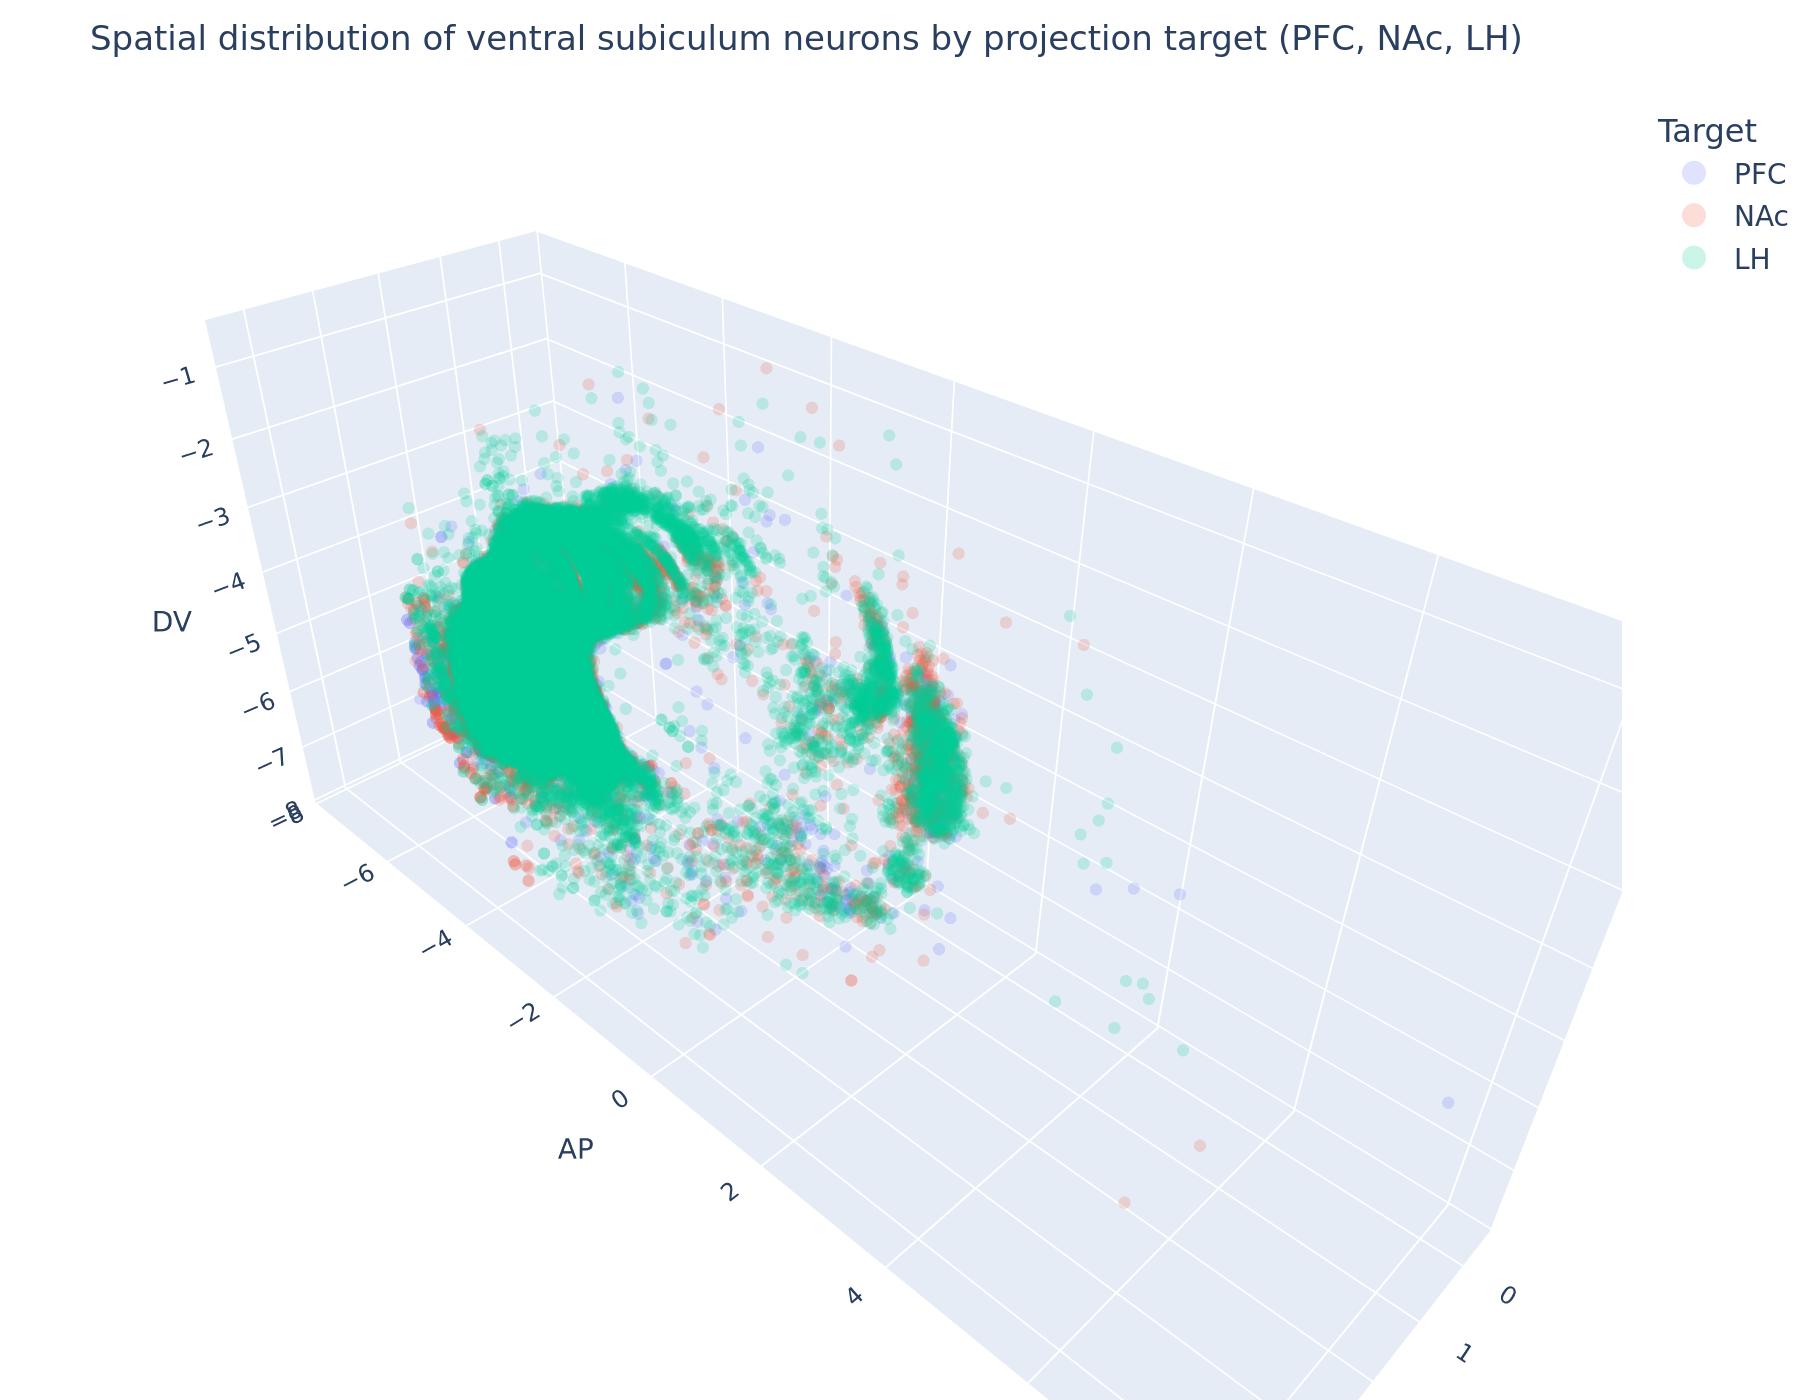

In [6]:
import plotly.express as px
from IPython.display import Image

# creating a 3d scatter plot
fig = px.scatter_3d(
    df,
    x = "ML", # anatomical coordinates
    y = "AP",
    z = "DV",
    color = "target", # colour on the graph indicates the neuron projection target corresponding to the column "target" in df
    opacity = 0.2,
    title = "Spatial distribution of ventral subiculum neurons by projection target (PFC, NAc, LH)"
)

fig.update_traces(
    marker = dict(size = 2) # smaller markers to reduce clutter in denser regions of the plot
)

fig.update_layout(
    width = 900,
    height = 700,
    margin = dict(l = 0, r = 0, b = 0, t = 50), # making more margin space at the top of the figure for the title
    legend = dict(
        title = dict(text = "Target", font = dict(size = 16)),
        font = dict(size = 14),
        itemsizing = "constant" # keeps legend marker sizes consistent, so that they can scale - prior to this line, the markers were tiny
    )
)

fig.write_image("projection_3d.png", scale=2)
Image(filename="projection_3d.png")

## Distribution of Neurons Along AP Axis
Plotting cumulative distribution of projection neurons along the three anatomical axes (AP, ML, DV)

==> allows comparison of spatial bias between projection targets

ECDF = cumulative proportion of neurons along an axis
    i.e. "at this AP value, what fraction of neurons are at/below it" - directly reflects spatial distribution

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



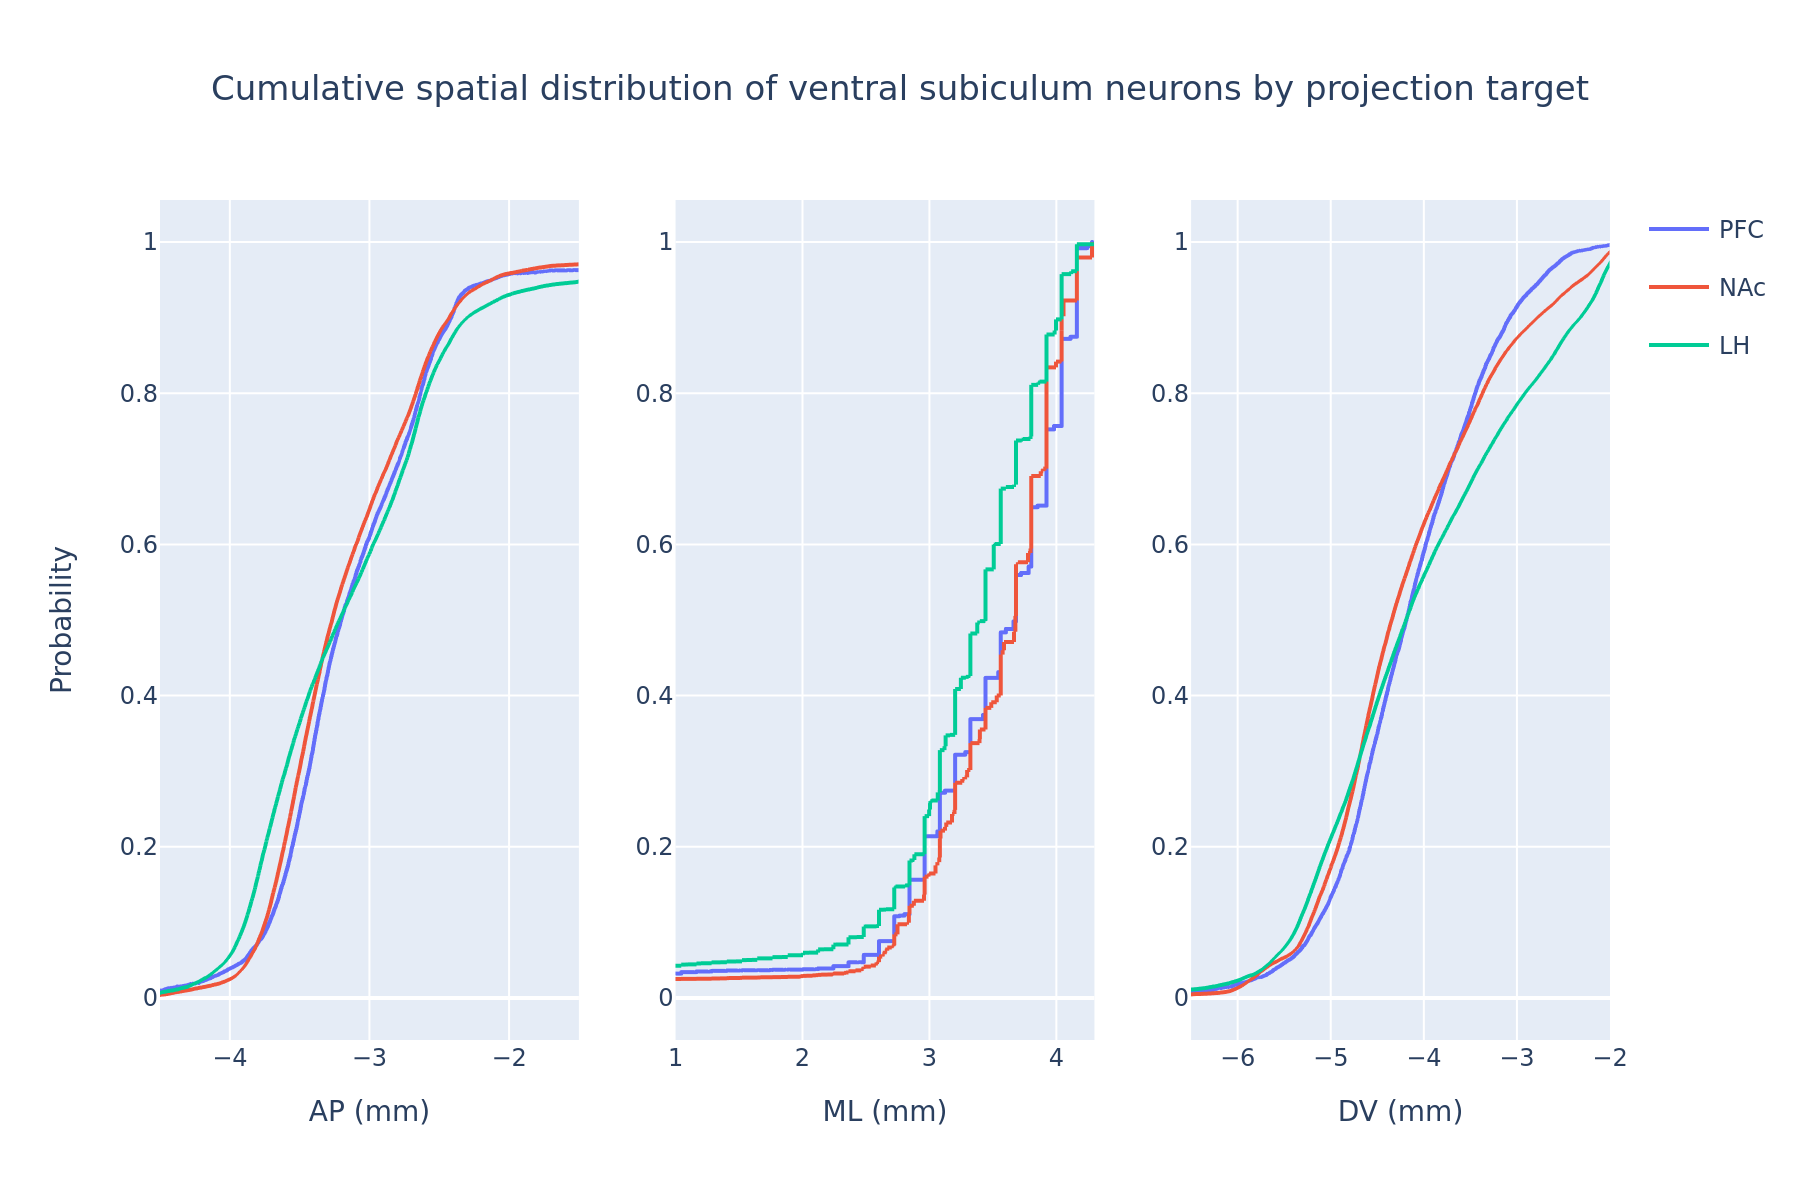

In [8]:
from plotly.subplots import make_subplots
import plotly.express as px
from IPython.display import Image

# create subplots (1 row, 3 columns) to compare cumulative distributions across AP, ML, DV
# to help identify which anatomical axis shows the strongest projection separation
fig = make_subplots(
    rows = 1, cols = 3
)

# --- AP ECDF ---
# ECDF shows the cumulative proportion of neurons up to each AP value
fig_ap = px.ecdf(
    df,
    x = "AP",
    color = "target" # separate curves for projections to PFC, NAc, LH
)

# add AP traces to first subplot (row=1, col=1)
# each ECDF (for PFC, NAc, LH) is stored as a separate trace
# loop through traces and add them to the subplot
for trace in fig_ap.data:
    trace.showlegend = True
    fig.add_trace(trace, row = 1, col = 1)

# --- ML ECDF ---
fig_ml = px.ecdf(
    df,
    x = "ML",
    color = "target"
)

# add ML traces to a second subplot & hide duplicate legends (already visible from AP subplot)
for trace in fig_ml.data:
    trace.showlegend = False
    fig.add_trace(trace, row = 1, col = 2)

# --- DV ECDF ---
fig_dv = px.ecdf(
    df,
    x = "DV",
    color = "target"
)

# add DV traces to third subplot & hide duplicate legend
for trace in fig_dv.data:
    trace.showlegend = False
    fig.add_trace(trace, row = 1, col = 3)

# overall figure layout settings
fig.update_layout(
    title_text = "Cumulative spatial distribution of ventral subiculum neurons by projection target", title_x = 0.5,
    width = 900,
    height = 600
)

# axis labels
fig.update_yaxes(title_text = "Probability", row = 1, col = 1)

fig.update_xaxes(title_text = "AP (mm)", row =1, col = 1)
fig.update_xaxes(title_text = "ML (mm)", row = 1, col = 2)
fig.update_xaxes(title_text = "DV (mm)", row = 1, col = 3)

# zoom into relevant ranges to better visualise separation between the projection groups
fig.update_xaxes(range = [-4.5, -1.5], row = 1, col = 1)
fig.update_xaxes(range = [1, 4.3], row = 1, col = 2)
fig.update_xaxes(range = [-6.5, -2], row = 1, col = 3)

fig.write_image("ecdf_subplots.png", scale=2)
Image(filename="ecdf_subplots.png")

## Comparison of AP Distributions by Projection Target
Visualise distribution of neuron positions using boxplots.
Compared to the cumulative distribution graph, this visualisation shows median, spread, and outliers for each projection target.

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/mnt/c/Users/Ellie/python-for-neuroscientists/workshop1/ws1venv/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



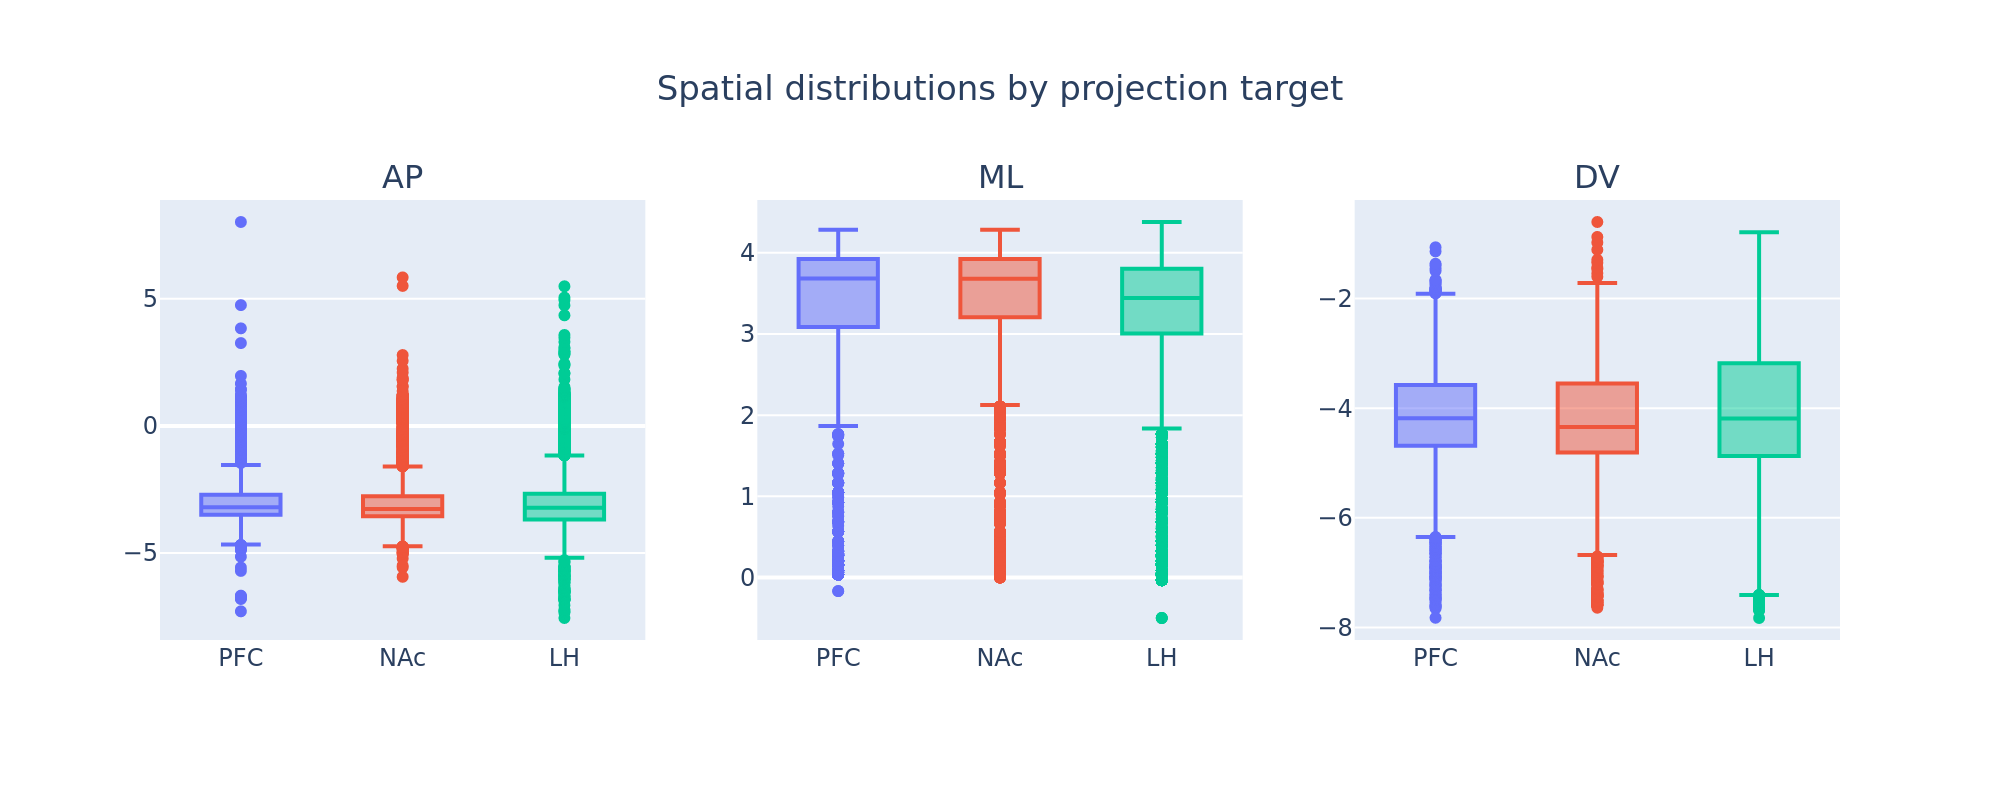

In [9]:
from plotly.subplots import make_subplots
from IPython.display import Image

# define colours for each projection target (matching previous plots) to ensure uniform colouring
color_map = {
    "PFC": "#636efa",
    "NAc": "#ef553b",
    "LH": "#00cc96"
}

# create subplots (1 row, 3 columns)
fig = make_subplots(
    rows = 1, cols = 3,
    subplot_titles = ("AP", "ML", "DV")
)

# AP
fig_ap = px.box(
    df,
    x = "target",
    y = "AP",
    color="target",
    color_discrete_map = color_map # discrete colours so each category gets its own colour (continuous is for things like temperature/gradients)
)

# add AP ECDF traces (one per projection target) to the first subplot
for trace in fig_ap.data:
    fig.add_trace(trace, row = 1, col = 1)

# ML
fig_ml = px.box(
    df,
    x = "target",
    y = "ML",
    color = "target",
    color_discrete_map = color_map
)
for trace in fig_ml.data:
    fig.add_trace(trace, row = 1, col = 2)

# DV
fig_dv = px.box(
    df,
    x = "target",
    y = "DV",
    color = "target",
    color_discrete_map = color_map
)
for trace in fig_dv.data:
    fig.add_trace(trace, row = 1, col = 3)

# adjust overall figure layout
fig.update_layout(
    title_text = "Spatial distributions by projection target",
    title_x = 0.5, # centre the title
    width = 1000,
    height = 400,
    showlegend = False # hide legend (already shown in earlier plots)
)

fig.write_image("boxplot_distribution.png", scale=2)
Image(filename="boxplot_distribution.png")

## Summary stats
Compute the mean spatial coordinates for each projection target AP, ML, DV, to get quantitative comparison of average spatial bias between groups.

In [ ]:
df.groupby("target")[["AP", "ML", "DV"]].mean()

The mean coordinates are similar across projection targets, with only small differences along each axis. This suggests that while there might be subtle spatial biases, the populations largely overlap rather than forming completely distincct regions.